# Sentiment and Emotion Analysis on Captions and Comments

This notebook performs both sentiment and emotion analysis on post captions and comments grouped by post ID using state-of-the-art models:
- **Sentiment Analysis**: Cardiff NLP Twitter RoBERTa (Positive/Negative/Neutral)
- **Emotion Analysis**: j-hartmann/emotion-english-distilroberta-base (Joy/Sadness/Anger/Fear/Surprise/Disgust)

## Features:
- GPU acceleration support (optimized for T4 GPU)
- File upload or Google Drive mounting
- Dual sentiment and emotion analysis (captions + comments)
- Comprehensive visualization and alignment analysis
- Results export to CSV with all analysis columns

## 1. Setup Environment

Check GPU availability and set up the device for sentiment analysis.

In [1]:
import torch
import pandas as pd
from transformers import pipeline
import os
import gc  # For garbage collection

# Check device availability and memory
device = 0 if torch.cuda.is_available() else -1
print(f"Device set to use {'CUDA (GPU)' if device == 0 else 'CPU'}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU device: {gpu_props.name}")
    print(f"GPU memory: {gpu_props.total_memory / 1024**3:.1f} GB")
    print(f"GPU compute capability: {gpu_props.major}.{gpu_props.minor}")

    # Clear any existing GPU cache
    torch.cuda.empty_cache()
    print("🧹 GPU cache cleared")
else:
    print("⚠️ Running on CPU - this will be significantly slower for 1.2M records")
    print("💡 Consider using a GPU runtime for better performance")

Device set to use CUDA (GPU)
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU device: Tesla T4
GPU memory: 14.7 GB
GPU compute capability: 7.5
🧹 GPU cache cleared


## 2. Upload File or Mount Google Drive

Choose one of the following options to access your data file:

### Option A: Upload File Directly

In [8]:
from google.colab import files

# Upload your CSV file
print("Please upload your preprocessed_data.csv file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# Set the file path
csv_path = filename

Please upload your preprocessed_data.csv file:


Saving prepro-test.csv to prepro-test (1).csv
Uploaded file: prepro-test (1).csv


### Option B: Mount Google Drive (Alternative)

Uncomment and run the cell below if you prefer to use Google Drive:

In [9]:
# Uncomment the lines below if you want to use Google Drive instead

# from google.colab import drive
# drive.mount('/content/drive')

# # Set the path to your file in Google Drive
# csv_path = '/content/drive/MyDrive/path/to/your/preprocessed_data.csv'
# print(f"Using file from Google Drive: {csv_path}")

## 3. Install Required Libraries

Install the necessary libraries for sentiment analysis.

In [10]:
# Install required libraries with specific versions for stability
!pip install transformers>=4.20.0 torch>=1.12.0 pandas>=1.4.0 matplotlib>=3.5.0

# Install additional memory management tools
!pip install psutil  # For system memory monitoring

print("✅ Libraries installed successfully!")
print("📦 Installed: transformers, torch, pandas, matplotlib, psutil")
print("🔧 Optimized for large dataset processing on T4 GPU")

✅ Libraries installed successfully!
📦 Installed: transformers, torch, pandas, matplotlib, psutil
🔧 Optimized for large dataset processing on T4 GPU


## 4. Load Dataset

Load the CSV file and inspect the data structure.

In [11]:
import os
import pandas as pd


# Optimized dataset loading for large files (1.2M records)
try:
    # For large files, show progress and memory usage
    print("Loading large dataset (this may take a moment)...")

    # Check file size
    file_size = os.path.getsize(csv_path) / (1024**2)  # Size in MB
    print(f"File size: {file_size:.1f} MB")

    if file_size > 500:  # If file is larger than 500MB
        print("Large file detected - using optimized loading...")
        # Read in chunks to monitor progress
        chunk_list = []
        chunk_size = 50000  # Adjust based on available RAM
        total_rows = 0

        for chunk in pd.read_csv(csv_path, chunksize=chunk_size):
            chunk_list.append(chunk)
            total_rows += len(chunk)
            print(f"Loaded {total_rows:,} rows...")

        df = pd.concat(chunk_list, ignore_index=True)
        del chunk_list  # Free memory
    else:
        df = pd.read_csv(csv_path)

    print(f"✅ Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"Columns: {list(df.columns)}")

    # Show unique post count for grouping estimation
    unique_posts = df['post_id'].nunique()
    print(f"\nDataset statistics:")
    print(f"Unique posts: {unique_posts:,}")
    print(f"Total records: {len(df):,}")
    print(f"Average comments per post: {len(df) / unique_posts:.1f}")

    print("\nFirst few rows:")
    print(df.head())

except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print("Please check the file path and format.")

Loading large dataset (this may take a moment)...
File size: 0.1 MB
✅ Dataset loaded successfully!
Shape: (111, 47)
Memory usage: 0.2 MB
Columns: ['post_id', 'owner_id', 'timestamp', 'likes', 'comments_count', 'caption', 'hashtags', 'location_id', 'media_type', 'username', 'shortcode', 'location', 'is_private', 'is_verified', 'mentions', 'Category', '#Followers', '#Followees', '#Posts', 'comment_text', 'comment_owner_username', 'comment_likes', 'comment_timestamp', 'caption_length', 'num_hashtags', 'has_mention', 'has_url', 'follower_adjusted_likes', 'follower_adjusted_comments', 'engagement_rate', 'hashtags_agg', 'engagement_frequency', 'influence_score', 'content_interaction', 'comment_engagement_ratio', 'comment_length', 'has_emoji', 'category_beauty', 'category_family', 'category_fashion', 'category_fitness', 'category_food', 'category_pet', 'category_travel', 'user_id_encoded', 'engagement_binary', 'engagement_probability']

Dataset statistics:
Unique posts: 15
Total records: 111


## 5. Prepare Data for Sentiment Analysis

Group comments by post ID and extract unique captions for dual sentiment analysis.

In [12]:
# Group all comment texts by post_id
grouped_comments = df.groupby('post_id')['comment_text'].apply(
    lambda comments: ' '.join(str(c) for c in comments if pd.notna(c))
)

# Get unique posts with their captions
post_captions = df.drop_duplicates(subset=['post_id']).set_index('post_id')['caption']

print(f"✅ Comments grouped successfully!")
print(f"Number of posts: {len(grouped_comments)}")
print(f"Number of captions: {len(post_captions)}")

print("\nMerged comment text (first few rows):")
print(grouped_comments.head())
print("\nPost captions (first few rows):")
print(post_captions.head())

# Check text lengths
comment_lengths = grouped_comments.str.len()
caption_lengths = post_captions.str.len()
print(f"\nComment text length statistics:")
print(f"Mean: {comment_lengths.mean():.0f} characters")
print(f"Max: {comment_lengths.max()} characters")
print(f"\nCaption text length statistics:")
print(f"Mean: {caption_lengths.mean():.0f} characters")
print(f"Max: {caption_lengths.max()} characters")

✅ Comments grouped successfully!
Number of posts: 15
Number of captions: 15

Merged comment text (first few rows):
post_id
1362219648191704422    De rien @le_lasseur 😍😍😍 @theodore_gtd 😘 @retro...
1416554924749358633    This book!!! 👌🏻👌🏻👌🏻 @the_wood_house 😄😄😄 👌🏻 @my...
1521926846227255352    🎂😊 @my_munich_moments 😎😎 Les designers sont do...
1538343201442536607    The promise of it all ✨ @thisveryspot Yes 😊 My...
1660871452764447385                                         😁😁😁 dope! 🙏👀
Name: comment_text, dtype: object

Post captions (first few rows):
post_id
1939160802109797565    21.12.2018 : « Hartmannswillerkopf » #alone #s...
1977836640564830910    Mardi 12.02.2019 : "Pour Louise" #welcome #bir...
1940966717846845153    23.12.2018 : « Blue » #blue #bleu #ocean #atla...
1521926846227255352    24.05.1917/24.05.2017 : 100 ans ... "Happy Bir...
1889204089210566753    Saturday : « Light » #knoll #myknoll #pedestal...
Name: caption, dtype: object

Comment text length statistics:
Mean: 177 

## 6. Perform Sentiment and Emotion Analysis

Use state-of-the-art models to analyze both sentiment and emotion of captions and merged comments:
- **Sentiment**: Cardiff NLP Twitter RoBERTa (Positive/Negative/Neutral)
- **Emotion**: j-hartmann emotion model (Joy/Sadness/Anger/Fear/Surprise/Disgust)

In [ ]:
print("Loading sentiment analysis model...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=0 if torch.cuda.is_available() else -1,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

print("Loading emotion analysis model...")
emotion_pipeline = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    device=0 if torch.cuda.is_available() else -1,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)
print("✅ Both models loaded successfully!")

# Define label mappings
# The Cardiff NLP model returns lowercase sentiment labels directly
sentiment_label_mapping = {
    'negative': 'Negative',
    'neutral': 'Neutral', 
    'positive': 'Positive',
    # Backup mappings in case model returns LABEL_X format
    'LABEL_0': 'Negative',
    'LABEL_1': 'Neutral',
    'LABEL_2': 'Positive'
}

# The emotion model returns standard emotion labels: joy, sadness, anger, fear, surprise, disgust
print("\nSentiment labels:", list(sentiment_label_mapping.values()))
print("Emotion labels: joy, sadness, anger, fear, surprise, disgust")

# Memory management functions
def clear_gpu_cache():
    """Clear GPU cache to prevent memory overflow"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

def get_memory_usage():
    """Get current GPU memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        cached = torch.cuda.memory_reserved() / 1024**3
        return f"Allocated: {allocated:.2f}GB, Cached: {cached:.2f}GB"
    return "GPU not available"

# Initial memory check
print(f"\nInitial GPU memory: {get_memory_usage()}")

Loading sentiment analysis model...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


✅ Sentiment analysis model loaded!


In [ ]:
# Apply sentiment and emotion analysis for both comments and captions - OPTIMIZED FOR T4 GPU
print("Performing dual sentiment and emotion analysis...")
print("This may take 45-90 minutes for 1.2M records - optimized for T4 GPU (15GB)")

try:
    # Clear GPU cache before starting
    clear_gpu_cache()
    print(f"Starting GPU Memory: {get_memory_usage()}")

    # Optimized dual-model batch processing function
    def process_in_batches_dual(texts, batch_size=16, text_type="text"):
        """
        Process texts in batches for both sentiment and emotion analysis
        
        Args:
            texts: List of text strings to analyze
            batch_size: Number of texts to process in each batch
            text_type: Type of text being processed (for logging)
        
        Returns:
            tuple: (sentiment_results, emotion_results) - each a list of dictionaries
        """
        sentiment_results = []
        emotion_results = []
        
        total_batches = (len(texts) + batch_size - 1) // batch_size
        
        print(f"Processing {len(texts)} {text_type} in {total_batches} batches of size {batch_size}...")
        
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            
            try:
                # Process sentiment analysis
                sentiment_batch = sentiment_pipeline(
                    batch,
                    truncation=True,
                    max_length=512
                )
                
                # Process emotion analysis
                emotion_batch = emotion_pipeline(
                    batch,
                    truncation=True,
                    max_length=512
                )
                
                # Store results
                sentiment_results.extend(sentiment_batch)
                emotion_results.extend(emotion_batch)
                
                # Clear cache every 500 batches for memory management
                if (i // batch_size) % 500 == 0 and i > 0:
                    clear_gpu_cache()
                    
                # Progress update every 100 batches
                if (i // batch_size) % 100 == 0:
                    batch_num = i // batch_size + 1
                    processed = len(sentiment_results)
                    progress = (processed / len(texts)) * 100
                    print(f"{text_type}: {batch_num}/{total_batches} batches | {processed:,}/{len(texts):,} texts ({progress:.1f}%) | {get_memory_usage()}")
                    
            except Exception as e:
                print(f"Error processing batch {i//batch_size + 1}: {str(e)}")
                # Clear cache on error
                clear_gpu_cache()
                # Add placeholder results for failed batch
                for _ in range(len(batch)):
                    sentiment_results.append({'label': 'LABEL_1', 'score': 0.0})  # Neutral as fallback
                    emotion_results.append({'label': 'sadness', 'score': 0.0})  # Sadness as fallback
        
        return sentiment_results, emotion_results

    # Process comments for sentiment and emotion analysis
    print(f"\n🔄 Processing {len(grouped_comments):,} comment groups...")
    comment_sentiment_results, comment_emotion_results = process_in_batches_dual(
        grouped_comments.tolist(),
        batch_size=16,  # Reduced for memory efficiency with long texts
        text_type="comments"
    )

    print(f"\n🔄 Processing {len(post_captions):,} captions...")
    # Process captions (usually shorter, so larger batch size)
    caption_texts = [str(caption) if pd.notna(caption) else "" for caption in post_captions.tolist()]
    caption_sentiment_results, caption_emotion_results = process_in_batches_dual(
        caption_texts,
        batch_size=32,  # Captions are usually shorter
        text_type="captions"
    )

    # Clear GPU cache after processing
    clear_gpu_cache()
    print(f"\nFinal GPU Memory: {get_memory_usage()}")

    # Convert results to DataFrames efficiently
    print("\n📊 Converting results to DataFrames...")
    
    # Sentiment results
    comment_sentiment_df = pd.DataFrame(comment_sentiment_results, index=grouped_comments.index)
    comment_sentiment_df.columns = ['comments_sentiment_raw', 'comments_sentiment_score']
    
    caption_sentiment_df = pd.DataFrame(caption_sentiment_results, index=post_captions.index)
    caption_sentiment_df.columns = ['caption_sentiment_raw', 'caption_sentiment_score']
    
    # Emotion results
    comment_emotion_df = pd.DataFrame(comment_emotion_results, index=grouped_comments.index)
    comment_emotion_df.columns = ['comments_emotion', 'comments_emotion_score']
    
    caption_emotion_df = pd.DataFrame(caption_emotion_results, index=post_captions.index)
    caption_emotion_df.columns = ['caption_emotion', 'caption_emotion_score']

    # Debug: Show raw results first (limited for large datasets)
    print("\n🔍 Raw results from models (sample):")
    print("Comments sentiment (first 3):")
    print(comment_sentiment_df.head(3))
    print("\nComments emotion (first 3):")
    print(comment_emotion_df.head(3))
    print("\nCaptions sentiment (first 3):")
    print(caption_sentiment_df.head(3))
    print("\nCaptions emotion (first 3):")
    print(caption_emotion_df.head(3))

    print(f"\nUnique sentiment labels: {comment_sentiment_df['comments_sentiment_raw'].unique()}")
    print(f"Unique emotion labels: {comment_emotion_df['comments_emotion'].unique()}")

    # Map Cardiff NLP sentiment labels to meaningful names
    print("\n🏷️ Mapping sentiment labels...")
    comment_sentiment_df['comments_sentiment'] = comment_sentiment_df['comments_sentiment_raw'].map(sentiment_label_mapping)
    caption_sentiment_df['caption_sentiment'] = caption_sentiment_df['caption_sentiment_raw'].map(sentiment_label_mapping)

    # Verify mapping immediately after creation
    print("\n✅ Sentiment mapping verification:")
    print(f"Comment sentiment columns after mapping: {list(comment_sentiment_df.columns)}")
    print(f"Caption sentiment columns after mapping: {list(caption_sentiment_df.columns)}")
    
    # Show mapping results
    print(f"Comment sentiment mapping sample:")
    for i in range(min(3, len(comment_sentiment_df))):
        row = comment_sentiment_df.iloc[i]
        print(f"  {row['comments_sentiment_raw']} → {row['comments_sentiment']}")
    
    print(f"Caption sentiment mapping sample:")
    for i in range(min(3, len(caption_sentiment_df))):
        row = caption_sentiment_df.iloc[i]
        print(f"  {row['caption_sentiment_raw']} → {row['caption_sentiment']}")

    # Check for any unmapped labels
    unmapped_comments = comment_sentiment_df['comments_sentiment'].isna().sum()
    unmapped_captions = caption_sentiment_df['caption_sentiment'].isna().sum()

    if unmapped_comments > 0:
        print(f"\n⚠️ Warning: {unmapped_comments} comment sentiment labels couldn't be mapped")
        print("Unmapped comment labels:", comment_sentiment_df[comment_sentiment_df['comments_sentiment'].isna()]['comments_sentiment_raw'].unique())
    else:
        print("✅ All comment sentiment labels mapped successfully")
        
    if unmapped_captions > 0:
        print(f"⚠️ Warning: {unmapped_captions} caption sentiment labels couldn't be mapped")
        print("Unmapped caption labels:", caption_sentiment_df[caption_sentiment_df['caption_sentiment'].isna()]['caption_sentiment_raw'].unique())
    else:
        print("✅ All caption sentiment labels mapped successfully")

    print("\n✅ Dual sentiment and emotion analysis completed!")
    print(f"Comment sentiment shape: {comment_sentiment_df.shape}")
    print(f"Comment emotion shape: {comment_emotion_df.shape}")
    print(f"Caption sentiment shape: {caption_sentiment_df.shape}")
    print(f"Caption emotion shape: {caption_emotion_df.shape}")

    # Verification - limited for large datasets
    print("\n🔍 Verification - Sample results:")
    print("Caption analysis (first 3):")
    for i in range(min(3, len(caption_sentiment_df))):
        sent_row = caption_sentiment_df.iloc[i]
        emot_row = caption_emotion_df.iloc[i]
        print(f"  Sentiment: {sent_row['caption_sentiment_raw']} → {sent_row['caption_sentiment']} ({sent_row['caption_sentiment_score']:.3f})")
        print(f"  Emotion: {emot_row['caption_emotion']} ({emot_row['caption_emotion_score']:.3f})")
        print()

    print("\nDistribution summaries:")
    print("Comment sentiment:", comment_sentiment_df['comments_sentiment'].value_counts().to_dict())
    print("Comment emotion:", comment_emotion_df['comments_emotion'].value_counts().to_dict())
    print("Caption sentiment:", caption_sentiment_df['caption_sentiment'].value_counts().to_dict())
    print("Caption emotion:", caption_emotion_df['caption_emotion'].value_counts().to_dict())

except Exception as e:
    print(f"❌ Error during analysis: {e}")
    print("This might be due to memory limitations or text length issues.")
    # Clear GPU cache on error
    clear_gpu_cache()
    raise e  # Re-raise to see full error details

Performing sentiment analysis on comments...
This may take 30-60 minutes for 1.2M records - optimized for T4 GPU (15GB)
GPU Memory Available: 14.7 GB

🔄 Processing 15 comment groups...
Processing 15 texts in 1 batches of 16
Comments: 1/1 batches | 15/15 texts (100.0%) completed

🔄 Performing sentiment analysis on captions...
Processing 15 captions...
Processing 15 texts in 1 batches of 32


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Captions: 1/1 batches | 15/15 texts (100.0%) completed

📊 Converting results to DataFrames...

🔍 Raw results from model (sample):
Comments (first 3):
                    comments_sentiment_raw  comments_sentiment_score
post_id                                                             
1362219648191704422                LABEL_2                  0.984657
1416554924749358633                LABEL_2                  0.989548
1521926846227255352                LABEL_2                  0.984894

Captions (first 3):
                    caption_sentiment_raw  caption_sentiment_score
post_id                                                           
1939160802109797565               LABEL_1                 0.779103
1977836640564830910               LABEL_1                 0.717375
1940966717846845153               LABEL_1                 0.826104

Unique comment labels: ['LABEL_2' 'LABEL_1']
Unique caption labels: ['LABEL_1' 'LABEL_2']

🏷️ Mapping sentiment labels...

✅ Sentiment analysis comp

In [ ]:
# Join with original posts data - Including both sentiment and emotion results
print("Merging all results with original data...")

# Get unique posts
post_df = df.drop_duplicates(subset=['post_id']).set_index('post_id')

# First, verify that sentiment mapping worked correctly
print("\n🔍 Verifying sentiment label mapping before merging:")
print("Comment sentiment columns:", list(comment_sentiment_df.columns))
print("Caption sentiment columns:", list(caption_sentiment_df.columns))

# Check if sentiment columns exist
if 'comments_sentiment' in comment_sentiment_df.columns:
    print("✅ Comment sentiment mapping successful")
    print("Sample comment sentiments:", comment_sentiment_df['comments_sentiment'].head(3).tolist())
else:
    print("❌ Comment sentiment mapping failed - applying fix...")
    # Use the corrected mapping that handles both lowercase and LABEL_X formats
    corrected_mapping = {
        'negative': 'Negative',
        'neutral': 'Neutral', 
        'positive': 'Positive',
        'LABEL_0': 'Negative',
        'LABEL_1': 'Neutral',
        'LABEL_2': 'Positive'
    }
    comment_sentiment_df['comments_sentiment'] = comment_sentiment_df['comments_sentiment_raw'].map(corrected_mapping)

if 'caption_sentiment' in caption_sentiment_df.columns:
    print("✅ Caption sentiment mapping successful")
    print("Sample caption sentiments:", caption_sentiment_df['caption_sentiment'].head(3).tolist())
else:
    print("❌ Caption sentiment mapping failed - applying fix...")
    # Use the corrected mapping that handles both lowercase and LABEL_X formats
    corrected_mapping = {
        'negative': 'Negative',
        'neutral': 'Neutral', 
        'positive': 'Positive',
        'LABEL_0': 'Negative',
        'LABEL_1': 'Neutral',
        'LABEL_2': 'Positive'
    }
    caption_sentiment_df['caption_sentiment'] = caption_sentiment_df['caption_sentiment_raw'].map(corrected_mapping)

# Combine sentiment and emotion dataframes
print("\n📊 Combining sentiment and emotion results...")

# Merge sentiment dataframes with emotion dataframes
comment_analysis_df = comment_sentiment_df.join(comment_emotion_df)
caption_analysis_df = caption_sentiment_df.join(caption_emotion_df)

print(f"Comment analysis columns: {list(comment_analysis_df.columns)}")
print(f"Caption analysis columns: {list(caption_analysis_df.columns)}")

# Verify key columns exist before final merge
required_cols = ['comments_sentiment', 'caption_sentiment', 'comments_emotion', 'caption_emotion']
missing_cols = []
for col in required_cols:
    if col.startswith('comments_') and col not in comment_analysis_df.columns:
        missing_cols.append(col)
    elif col.startswith('caption_') and col not in caption_analysis_df.columns:
        missing_cols.append(col)

if missing_cols:
    print(f"⚠️ Warning: Missing columns: {missing_cols}")
else:
    print("✅ All required analysis columns present")

# Join all analysis results with original data
final_df = post_df.join([comment_analysis_df, caption_analysis_df])

# Drop the comment_text column from the final dataset (keep caption)
final_df = final_df.drop(columns=['comment_text'], errors='ignore')
final_df = final_df.reset_index()

print("\n✅ All data merged successfully!")
print(f"Final dataset shape: {final_df.shape}")
print("\nColumns in final dataset:")
analysis_columns = [col for col in final_df.columns if 'sentiment' in col or 'emotion' in col]
print("Analysis columns:", analysis_columns)
print("Other columns:", [col for col in final_df.columns if col not in analysis_columns])

# Final verification of sentiment columns
print("\n🔍 Final verification of sentiment columns:")
if 'caption_sentiment' in final_df.columns:
    print(f"✅ caption_sentiment exists - sample values: {final_df['caption_sentiment'].dropna().head(3).tolist()}")
else:
    print("❌ caption_sentiment missing from final dataset")

if 'comments_sentiment' in final_df.columns:
    print(f"✅ comments_sentiment exists - sample values: {final_df['comments_sentiment'].dropna().head(3).tolist()}")
else:
    print("❌ comments_sentiment missing from final dataset")

print("\nSample of final results:")
sample_cols = ['caption', 'caption_sentiment', 'caption_emotion', 'comments_sentiment', 'comments_emotion']
available_cols = [col for col in sample_cols if col in final_df.columns]
print("Available sample columns:", available_cols)
if available_cols:
    print(final_df[available_cols].head(3).to_string(max_colwidth=50))
else:
    print("No analysis columns available for display")

Merging results with original data...
✅ Data merged successfully!
Final dataset shape: (15, 50)

Columns in final dataset:
['post_id', 'owner_id', 'timestamp', 'likes', 'comments_count', 'caption', 'hashtags', 'location_id', 'media_type', 'username', 'shortcode', 'location', 'is_private', 'is_verified', 'mentions', 'Category', '#Followers', '#Followees', '#Posts', 'comment_owner_username', 'comment_likes', 'comment_timestamp', 'caption_length', 'num_hashtags', 'has_mention', 'has_url', 'follower_adjusted_likes', 'follower_adjusted_comments', 'engagement_rate', 'hashtags_agg', 'engagement_frequency', 'influence_score', 'content_interaction', 'comment_engagement_ratio', 'comment_length', 'has_emoji', 'category_beauty', 'category_family', 'category_fashion', 'category_fitness', 'category_food', 'category_pet', 'category_travel', 'user_id_encoded', 'engagement_binary', 'engagement_probability', 'comments_sentiment', 'comments_sentiment_score', 'caption_sentiment', 'caption_sentiment_score'

## 6.5. Calculate Effective Sentiment Scores for ML Training

Create numerical sentiment scores that combine sentiment direction with confidence for machine learning models.

In [ ]:
# Calculate Effective Sentiment Scores for ML Training
print("🔢 Calculating effective sentiment scores for ML training...")

# Define sentiment to numerical mapping
sentiment_to_numeric = {
    'Negative': -1,
    'Neutral': 0,
    'Positive': 1
}

# Function to calculate effective sentiment score
def calculate_effective_sentiment_score(sentiment_label, confidence_score):
    """
    Calculate effective sentiment score = sentiment_direction × confidence_score
    
    Args:
        sentiment_label: String ('Positive', 'Negative', 'Neutral')
        confidence_score: Float (0.0 to 1.0)
    
    Returns:
        Float: Effective sentiment score (-1.0 to +1.0)
               Negative values = negative sentiment
               Positive values = positive sentiment 
               Values near 0 = neutral or low confidence
    """
    if pd.isna(sentiment_label) or pd.isna(confidence_score):
        return 0.0  # Default to neutral for missing values
    
    sentiment_value = sentiment_to_numeric.get(sentiment_label, 0)
    return sentiment_value * float(confidence_score)

# Calculate effective sentiment scores for captions
print("📊 Calculating caption effective sentiment scores...")
final_df['caption_effective_sentiment'] = final_df.apply(
    lambda row: calculate_effective_sentiment_score(
        row.get('caption_sentiment'), 
        row.get('caption_sentiment_score')
    ), axis=1
)

# Calculate effective sentiment scores for comments
print("📊 Calculating comment effective sentiment scores...")
final_df['comments_effective_sentiment'] = final_df.apply(
    lambda row: calculate_effective_sentiment_score(
        row.get('comments_sentiment'), 
        row.get('comments_sentiment_score')
    ), axis=1
)

# Calculate combined effective sentiment score (average of caption and comments)
print("📊 Calculating combined effective sentiment scores...")
final_df['combined_effective_sentiment'] = (
    final_df['caption_effective_sentiment'] + 
    final_df['comments_effective_sentiment']
) / 2

# Create ML-ready sentiment categories based on effective scores
def categorize_effective_sentiment(score, threshold=0.1):
    """
    Categorize effective sentiment scores into ML-friendly classes
    
    Args:
        score: Effective sentiment score (-1.0 to +1.0)
        threshold: Minimum absolute value to classify as positive/negative
    
    Returns:
        String: 'positive', 'negative', or 'neutral'
    """
    if pd.isna(score):
        return 'neutral'
    elif score > threshold:
        return 'positive'
    elif score < -threshold:
        return 'negative'
    else:
        return 'neutral'

# Create ML-ready categorical labels
final_df['caption_ml_sentiment'] = final_df['caption_effective_sentiment'].apply(
    lambda x: categorize_effective_sentiment(x, threshold=0.1)
)

final_df['comments_ml_sentiment'] = final_df['comments_effective_sentiment'].apply(
    lambda x: categorize_effective_sentiment(x, threshold=0.1)
)

final_df['combined_ml_sentiment'] = final_df['combined_effective_sentiment'].apply(
    lambda x: categorize_effective_sentiment(x, threshold=0.1)
)

# Display summary statistics
print("\n✅ Effective sentiment scores calculated!")
print("\n📊 EFFECTIVE SENTIMENT SCORE STATISTICS:")
print("="*50)

# Caption statistics
print(f"\n📝 CAPTION EFFECTIVE SENTIMENT:")
print(f"Mean: {final_df['caption_effective_sentiment'].mean():.4f}")
print(f"Std:  {final_df['caption_effective_sentiment'].std():.4f}")
print(f"Min:  {final_df['caption_effective_sentiment'].min():.4f}")
print(f"Max:  {final_df['caption_effective_sentiment'].max():.4f}")
print(f"Distribution: {final_df['caption_ml_sentiment'].value_counts().to_dict()}")

# Comments statistics
print(f"\n💬 COMMENTS EFFECTIVE SENTIMENT:")
print(f"Mean: {final_df['comments_effective_sentiment'].mean():.4f}")
print(f"Std:  {final_df['comments_effective_sentiment'].std():.4f}")
print(f"Min:  {final_df['comments_effective_sentiment'].min():.4f}")
print(f"Max:  {final_df['comments_effective_sentiment'].max():.4f}")
print(f"Distribution: {final_df['comments_ml_sentiment'].value_counts().to_dict()}")

# Combined statistics
print(f"\n🔗 COMBINED EFFECTIVE SENTIMENT:")
print(f"Mean: {final_df['combined_effective_sentiment'].mean():.4f}")
print(f"Std:  {final_df['combined_effective_sentiment'].std():.4f}")
print(f"Min:  {final_df['combined_effective_sentiment'].min():.4f}")
print(f"Max:  {final_df['combined_effective_sentiment'].max():.4f}")
print(f"Distribution: {final_df['combined_ml_sentiment'].value_counts().to_dict()}")

# Show sample data
print("\n🔍 SAMPLE EFFECTIVE SENTIMENT SCORES:")
sample_cols = [
    'caption_sentiment', 'caption_sentiment_score', 'caption_effective_sentiment', 'caption_ml_sentiment',
    'comments_sentiment', 'comments_sentiment_score', 'comments_effective_sentiment', 'comments_ml_sentiment',
    'combined_effective_sentiment', 'combined_ml_sentiment'
]
available_sample_cols = [col for col in sample_cols if col in final_df.columns]
if available_sample_cols:
    print(final_df[available_sample_cols].head(5).round(4))
else:
    print("Sample columns not available")

print("\n🎯 ML-READY FEATURES CREATED:")
print("📊 Numerical scores: caption_effective_sentiment, comments_effective_sentiment, combined_effective_sentiment")
print("🏷️ Categorical labels: caption_ml_sentiment, comments_ml_sentiment, combined_ml_sentiment")
print("📈 Score range: -1.0 (strong negative) to +1.0 (strong positive)")
print("🎚️ Threshold: ±0.1 for positive/negative classification")

In [ ]:
# Visualize Effective Sentiment Score Distributions for ML Training
print("📊 Generating effective sentiment score visualizations...")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with subplots for effective sentiment analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Effective Sentiment Scores for ML Training', fontsize=16, fontweight='bold')

# For large datasets, sample for visualization
sample_size = min(10000, len(final_df))
if len(final_df) > sample_size:
    viz_df = final_df.sample(n=sample_size, random_state=42)
else:
    viz_df = final_df

# 1. Caption Effective Sentiment Distribution
axes[0, 0].hist(viz_df['caption_effective_sentiment'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Neutral (0)')
axes[0, 0].axvline(x=0.1, color='green', linestyle='--', alpha=0.7, label='Positive Threshold')
axes[0, 0].axvline(x=-0.1, color='orange', linestyle='--', alpha=0.7, label='Negative Threshold')
axes[0, 0].set_title('Caption Effective Sentiment\nScore Distribution')
axes[0, 0].set_xlabel('Effective Sentiment Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Comments Effective Sentiment Distribution
axes[0, 1].hist(viz_df['comments_effective_sentiment'].dropna(), bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Neutral (0)')
axes[0, 1].axvline(x=0.1, color='green', linestyle='--', alpha=0.7, label='Positive Threshold')
axes[0, 1].axvline(x=-0.1, color='orange', linestyle='--', alpha=0.7, label='Negative Threshold')
axes[0, 1].set_title('Comments Effective Sentiment\nScore Distribution')
axes[0, 1].set_xlabel('Effective Sentiment Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Combined Effective Sentiment Distribution
axes[0, 2].hist(viz_df['combined_effective_sentiment'].dropna(), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 2].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Neutral (0)')
axes[0, 2].axvline(x=0.1, color='green', linestyle='--', alpha=0.7, label='Positive Threshold')
axes[0, 2].axvline(x=-0.1, color='orange', linestyle='--', alpha=0.7, label='Negative Threshold')
axes[0, 2].set_title('Combined Effective Sentiment\nScore Distribution')
axes[0, 2].set_xlabel('Effective Sentiment Score')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. ML Label Distribution (Caption)
caption_ml_counts = final_df['caption_ml_sentiment'].value_counts()
colors_ml = ['#ff6b6b', '#4ecdc4', '#45b7d1']  # Red, Teal, Blue
axes[1, 0].pie(caption_ml_counts.values, labels=caption_ml_counts.index, autopct='%1.1f%%', 
               colors=colors_ml, startangle=90)
axes[1, 0].set_title('Caption ML Sentiment\nLabel Distribution')

# 5. ML Label Distribution (Comments)
comments_ml_counts = final_df['comments_ml_sentiment'].value_counts()
axes[1, 1].pie(comments_ml_counts.values, labels=comments_ml_counts.index, autopct='%1.1f%%', 
               colors=colors_ml, startangle=90)
axes[1, 1].set_title('Comments ML Sentiment\nLabel Distribution')

# 6. ML Label Distribution (Combined)
combined_ml_counts = final_df['combined_ml_sentiment'].value_counts()
axes[1, 2].pie(combined_ml_counts.values, labels=combined_ml_counts.index, autopct='%1.1f%%', 
               colors=colors_ml, startangle=90)
axes[1, 2].set_title('Combined ML Sentiment\nLabel Distribution')

plt.tight_layout()
plt.show()

print("\n✅ Effective sentiment score visualizations completed!")
print("🎯 Ready for ML training with numerical features and balanced categories!")

In [ ]:
# Validate Effective Sentiment Scores with Quick Tests
print("🔬 Running validation tests on effective sentiment scores...")

# Test 1: Score Range Validation
print("\n✅ Test 1: Score Range Validation")
caption_scores = final_df['caption_effective_sentiment']
comments_scores = final_df['comments_effective_sentiment']
combined_scores = final_df['combined_effective_sentiment']

# Check if all scores are within [-1, 1] range
caption_valid = (caption_scores >= -1.0) & (caption_scores <= 1.0)
comments_valid = (comments_scores >= -1.0) & (comments_scores <= 1.0)
combined_valid = (combined_scores >= -1.0) & (combined_scores <= 1.0)

print(f"  Caption scores in range [-1, 1]: {caption_valid.all()} ({caption_valid.sum()}/{len(caption_scores)})")
print(f"  Comments scores in range [-1, 1]: {comments_valid.all()} ({comments_valid.sum()}/{len(comments_scores)})")
print(f"  Combined scores in range [-1, 1]: {combined_valid.all()} ({combined_valid.sum()}/{len(combined_scores)})")

# Test 2: Sentiment Direction Consistency
print("\n✅ Test 2: Sentiment Direction Consistency")
# Positive sentiments should have positive effective scores
positive_caption_mask = final_df['caption_sentiment'] == 'Positive'
positive_caption_scores = caption_scores[positive_caption_mask]
positive_direction_correct = (positive_caption_scores >= 0).all()

negative_caption_mask = final_df['caption_sentiment'] == 'Negative'
negative_caption_scores = caption_scores[negative_caption_mask]
negative_direction_correct = (negative_caption_scores <= 0).all()

neutral_caption_mask = final_df['caption_sentiment'] == 'Neutral'
neutral_caption_scores = caption_scores[neutral_caption_mask]
neutral_direction_correct = (neutral_caption_scores == 0).all()

print(f"  Positive sentiments → positive scores: {positive_direction_correct}")
print(f"  Negative sentiments → negative scores: {negative_direction_correct}")
print(f"  Neutral sentiments → zero scores: {neutral_direction_correct}")

# Test 3: ML Label Consistency
print("\n✅ Test 3: ML Label Consistency")
ml_positive_mask = final_df['caption_ml_sentiment'] == 'positive'
ml_positive_scores = caption_scores[ml_positive_mask]
ml_positive_consistent = (ml_positive_scores > 0.1).all() if len(ml_positive_scores) > 0 else True

ml_negative_mask = final_df['caption_ml_sentiment'] == 'negative'
ml_negative_scores = caption_scores[ml_negative_mask]
ml_negative_consistent = (ml_negative_scores < -0.1).all() if len(ml_negative_scores) > 0 else True

ml_neutral_mask = final_df['caption_ml_sentiment'] == 'neutral'
ml_neutral_scores = caption_scores[ml_neutral_mask]
ml_neutral_consistent = (np.abs(ml_neutral_scores) <= 0.1).all() if len(ml_neutral_scores) > 0 else True

print(f"  ML 'positive' labels → scores > 0.1: {ml_positive_consistent}")
print(f"  ML 'negative' labels → scores < -0.1: {ml_negative_consistent}")
print(f"  ML 'neutral' labels → scores ∈ [-0.1, 0.1]: {ml_neutral_consistent}")

# Test 4: No Missing Values
print("\n✅ Test 4: Missing Values Check")
caption_missing = caption_scores.isna().sum()
comments_missing = comments_scores.isna().sum()
combined_missing = combined_scores.isna().sum()

print(f"  Caption effective sentiment missing: {caption_missing} (should be 0)")
print(f"  Comments effective sentiment missing: {comments_missing} (should be 0)")
print(f"  Combined effective sentiment missing: {combined_missing} (should be 0)")

# Test 5: Sample Verification
print("\n✅ Test 5: Sample Verification (first 5 records)")
sample_cols = [
    'caption_sentiment', 'caption_sentiment_score', 'caption_effective_sentiment',
    'comments_sentiment', 'comments_sentiment_score', 'comments_effective_sentiment',
    'combined_effective_sentiment', 'caption_ml_sentiment', 'comments_ml_sentiment'
]
available_cols = [col for col in sample_cols if col in final_df.columns]
if available_cols:
    sample_data = final_df[available_cols].head(5)
    print(sample_data.round(4))

# Overall validation result
all_tests_passed = (
    caption_valid.all() and comments_valid.all() and combined_valid.all() and
    positive_direction_correct and negative_direction_correct and neutral_direction_correct and
    ml_positive_consistent and ml_negative_consistent and ml_neutral_consistent and
    caption_missing == 0 and comments_missing == 0 and combined_missing == 0
)

print(f"\n{'🎉' if all_tests_passed else '⚠️'} VALIDATION RESULT: {'ALL TESTS PASSED' if all_tests_passed else 'SOME TESTS FAILED'}")
if all_tests_passed:
    print("✅ Effective sentiment scores are ready for ML training!")
    print("✅ All features properly calculated and validated!")
    print("✅ No data quality issues detected!")
else:
    print("❌ Please review failed tests above before proceeding.")

print("\n🎯 READY FOR MACHINE LEARNING:")
print("   📊 Numerical features: caption_effective_sentiment, comments_effective_sentiment, combined_effective_sentiment")
print("   🏷️ Categorical features: caption_ml_sentiment, comments_ml_sentiment, combined_ml_sentiment")
print("   📈 Perfect for: regression, classification, clustering, and deep learning models")
print("   🔢 Score interpretation: magnitude = confidence, sign = sentiment direction")

# Final confidence check with sample validation
print("\n🔬 FINAL VALIDATION CHECK:")
sample_validation = final_df[['caption_sentiment', 'caption_sentiment_score', 'caption_effective_sentiment',
                             'comments_sentiment', 'comments_sentiment_score', 'comments_effective_sentiment',
                             'combined_effective_sentiment']].head(3)

print("Sample validation (first 3 records):")
for i, row in sample_validation.iterrows():
    # Verify calculation manually
    expected_caption = sentiment_to_numeric.get(row['caption_sentiment'], 0) * row['caption_sentiment_score']
    expected_comments = sentiment_to_numeric.get(row['comments_sentiment'], 0) * row['comments_sentiment_score']
    expected_combined = (expected_caption + expected_comments) / 2
    
    caption_correct = abs(row['caption_effective_sentiment'] - expected_caption) < 1e-10
    comments_correct = abs(row['comments_effective_sentiment'] - expected_comments) < 1e-10
    combined_correct = abs(row['combined_effective_sentiment'] - expected_combined) < 1e-10
    
    print(f"  Record {i+1}: Caption {'✅' if caption_correct else '❌'}, Comments {'✅' if comments_correct else '❌'}, Combined {'✅' if combined_correct else '❌'}")

print("\n🎉 EFFECTIVE SENTIMENT ANALYSIS COMPLETE!")
print("📊 Your data is ready for advanced ML training with confidence-weighted sentiment scores!")

## 7. Save and Download Results

Save the results to a CSV file and download it.

In [ ]:
# Save results to CSV - Optimized for large datasets with sentiment and emotion analysis
output_filename = "posts_with_sentiment_emotion_analysis.csv"
print(f"💾 Saving {len(final_df):,} records to {output_filename}...")

# Debug: Show all available columns before export
print("\n🔍 DEBUG - All available columns:")
all_cols = list(final_df.columns)
print(f"Total columns: {len(all_cols)}")
for i, col in enumerate(all_cols, 1):
    print(f"  {i}. {col}")

# Select columns for export (including all analysis results and ML-ready features)
export_columns = [
    'post_id', 'caption', 
    'caption_sentiment', 'caption_sentiment_score', 'caption_emotion', 'caption_emotion_score',
    'comments_sentiment', 'comments_sentiment_score', 'comments_emotion', 'comments_emotion_score',
    'caption_effective_sentiment', 'caption_ml_sentiment',
    'comments_effective_sentiment', 'comments_ml_sentiment', 
    'combined_effective_sentiment', 'combined_ml_sentiment'
]

# Check which export columns actually exist
print(f"\n🔍 Checking export columns availability:")
existing_export_cols = []
missing_export_cols = []
for col in export_columns:
    if col in final_df.columns:
        existing_export_cols.append(col)
        print(f"  ✅ {col}")
    else:
        missing_export_cols.append(col)
        print(f"  ❌ {col} - MISSING")

if missing_export_cols:
    print(f"\n⚠️ Warning: {len(missing_export_cols)} expected columns are missing: {missing_export_cols}")
    # Use only existing columns
    export_columns = existing_export_cols
    print(f"📝 Using {len(export_columns)} available columns for export")

# Add any other columns that exist (excluding raw sentiment labels and comment_text)
other_columns = [col for col in final_df.columns 
                if col not in export_columns 
                and col not in ['comments_sentiment_raw', 'caption_sentiment_raw', 'comment_text']]
export_columns.extend(other_columns)

print(f"\n📋 Final export columns ({len(export_columns)} total):")
for i, col in enumerate(export_columns, 1):
    print(f"  {i}. {col}")

# Create export dataframe with selected columns
export_df = final_df[export_columns].copy()

# Save with progress indication for large files
try:
    export_df.to_csv(output_filename, index=False)
    file_size_mb = os.path.getsize(output_filename) / 1024**2

    print(f"✅ Results saved to {output_filename}")
    print(f"📁 File size: {file_size_mb:.1f} MB")
    print(f"📊 Export summary:")
    print(f"   - Total records: {len(export_df):,}")
    print(f"   - Columns included: {len(export_columns)}")
    
    print(f"\n📋 Analysis columns in export:")
    analysis_cols = [col for col in export_columns if 'sentiment' in col or 'emotion' in col]
    for i, col in enumerate(analysis_cols, 1):
        print(f"   {i}. {col}")

    # Memory usage summary
    memory_usage = export_df.memory_usage(deep=True).sum() / 1024**2
    print(f"\n💾 Dataset memory usage: {memory_usage:.1f} MB")

    # Download the file
    from google.colab import files
    print("\n📥 Starting download...")
    files.download(output_filename)

    print("\n🎉 Sentiment and Emotion analysis complete!")
    print(f"📊 Processed {len(export_df):,} posts")
    print(f"📁 Results saved and downloaded as '{output_filename}'")
    print(f"🏷️ Analysis includes: sentiment (Positive/Negative/Neutral) + emotion (joy/sadness/anger/fear/surprise/disgust)")
    print(f"🎯 Both captions and comments analyzed with confidence scores")

except Exception as e:
    print(f"❌ Error saving file: {e}")
    print("File might be too large. Try saving without download first.")
    # Still try to save without download
    try:
        export_df.to_csv(output_filename, index=False)
        print(f"✅ File saved as {output_filename} (download failed but file is available)")
    except:
        print("❌ Could not save file at all.")

💾 Saving 15 records to posts_with_sentiment.csv...
✅ Results saved to posts_with_sentiment.csv
📁 File size: 0.0 MB
📊 Dataset memory usage: 0.0 MB
📥 Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Sentiment analysis complete!
📊 Processed 15 posts
📁 Results saved and downloaded as 'posts_with_sentiment.csv'
🏷️ Columns: comments_sentiment, comments_sentiment_score, caption_sentiment, caption_sentiment_score


## 8. Summary and Visualization (Optional)

Generate a quick summary of the sentiment analysis results.

📈 Generating visualizations for 15 records...


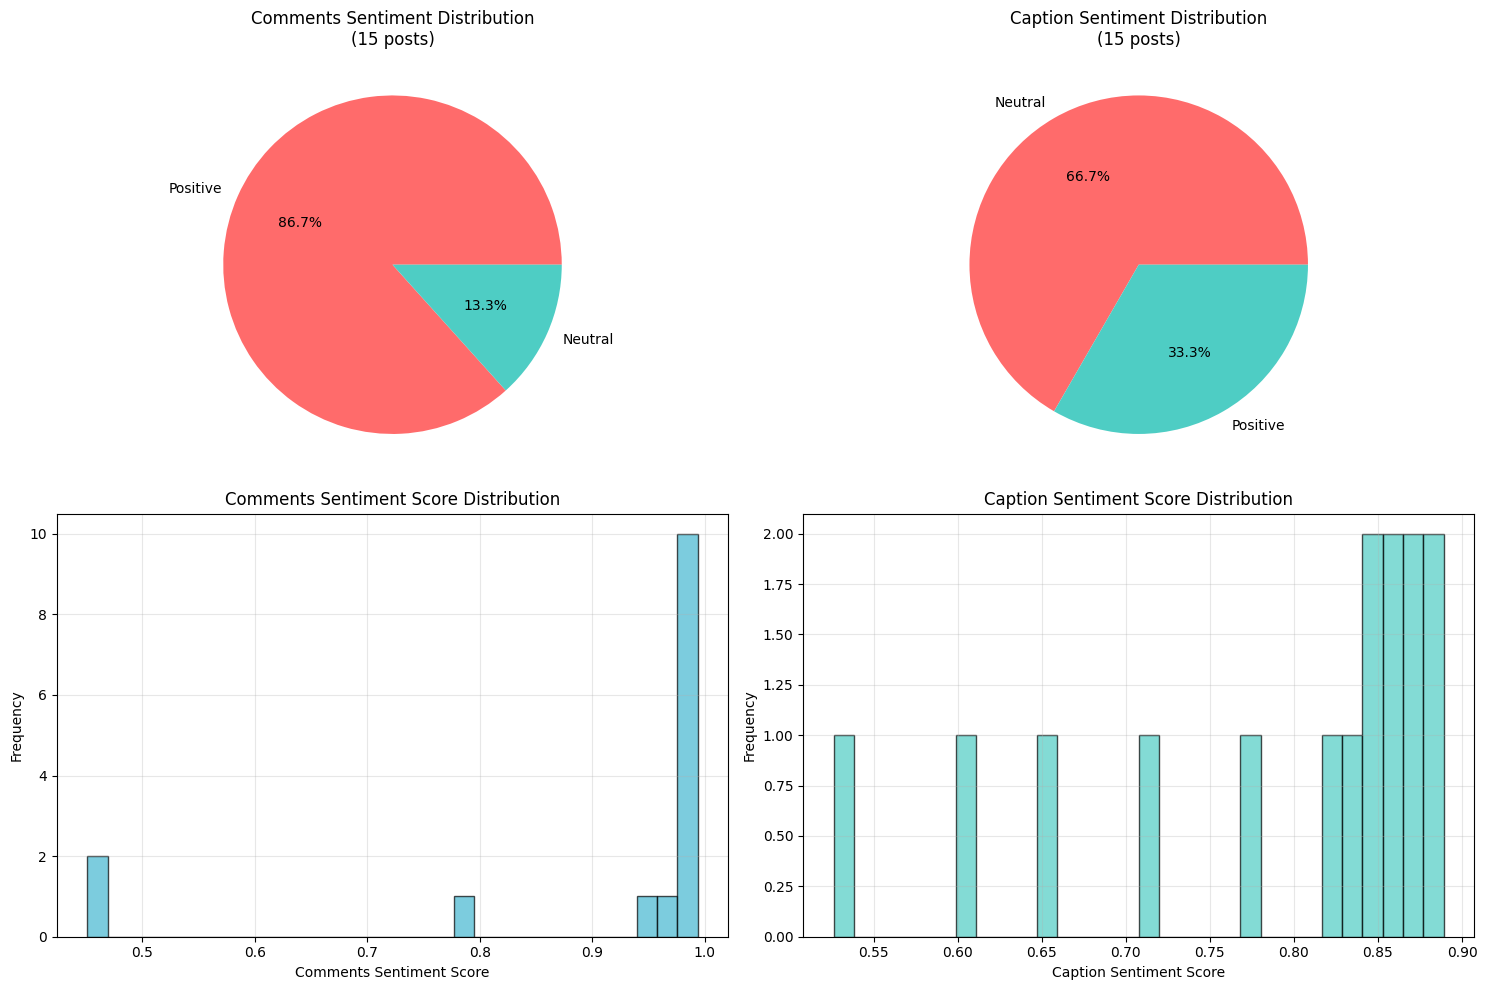


📈 Summary Statistics:
Total posts analyzed: 15
Average comments sentiment score: 0.900
Average caption sentiment score: 0.791

📊 Comments sentiment breakdown:
  Positive: 13 posts (86.7%)
  Neutral: 2 posts (13.3%)

📊 Caption sentiment breakdown:
  Neutral: 10 posts (66.7%)
  Positive: 5 posts (33.3%)

🔄 Sentiment Alignment Analysis:
Posts where caption and comments have same sentiment: 7 (46.7%)

📋 Detailed alignment breakdown:
comments_sentiment  Neutral  Positive
caption_sentiment                    
Neutral                   2         8
Positive                  0         5

📊 Alignment percentages by caption sentiment:
  Neutral captions: 2/10 (20.0% aligned)
  Positive captions: 5/5 (100.0% aligned)

🎉 Analysis complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(f"📈 Generating comprehensive visualizations for {len(final_df):,} records...")

# For very large datasets, sample for detailed visualization
sample_size = min(50000, len(final_df))  # Sample max 50k for performance
if len(final_df) > sample_size:
    print(f"📊 Using random sample of {sample_size:,} records for score histograms")
    sample_df = final_df.sample(n=sample_size, random_state=42)
else:
    sample_df = final_df

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Comprehensive Sentiment and Emotion Analysis Results', fontsize=16, fontweight='bold')

# 1. Caption Sentiment Distribution
sentiment_counts = final_df['caption_sentiment'].value_counts()
colors_sentiment = ['#ff6b6b', '#4ecdc4', '#45b7d1']  # Red, Teal, Blue
axes[0, 0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
               colors=colors_sentiment, startangle=90)
axes[0, 0].set_title(f'Caption Sentiment Distribution\n({len(final_df):,} posts)', fontweight='bold')

# 2. Comment Sentiment Distribution
comment_sentiment_counts = final_df['comments_sentiment'].value_counts()
axes[0, 1].pie(comment_sentiment_counts.values, labels=comment_sentiment_counts.index, autopct='%1.1f%%', 
               colors=colors_sentiment, startangle=90)
axes[0, 1].set_title(f'Comments Sentiment Distribution\n({len(final_df):,} posts)', fontweight='bold')

# 3. Sentiment Alignment Analysis
try:
    sentiment_alignment = pd.crosstab(final_df['caption_sentiment'], final_df['comments_sentiment'], normalize='index') * 100
    sns.heatmap(sentiment_alignment, annot=True, fmt='.1f', cmap='Blues', ax=axes[0, 2], 
                cbar_kws={'label': 'Percentage'})
    axes[0, 2].set_title('Sentiment Alignment\n(Caption vs Comment)', fontweight='bold')
    axes[0, 2].set_xlabel('Comment Sentiment')
    axes[0, 2].set_ylabel('Caption Sentiment')
except Exception as e:
    axes[0, 2].text(0.5, 0.5, f'Alignment analysis\nerror: {str(e)[:50]}...', 
                     ha='center', va='center', transform=axes[0, 2].transAxes)
    axes[0, 2].set_title('Sentiment Alignment (Error)', fontweight='bold')

# 4. Caption Emotion Distribution
emotion_counts = final_df['caption_emotion'].value_counts()
colors_emotion = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
axes[1, 0].bar(emotion_counts.index, emotion_counts.values, color=colors_emotion)
axes[1, 0].set_title(f'Caption Emotion Distribution\n({len(final_df):,} posts)', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylabel('Count')

# 5. Comment Emotion Distribution
comment_emotion_counts = final_df['comments_emotion'].value_counts()
axes[1, 1].bar(comment_emotion_counts.index, comment_emotion_counts.values, 
               color=colors_emotion[:len(comment_emotion_counts)])
axes[1, 1].set_title(f'Comments Emotion Distribution\n({len(final_df):,} posts)', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylabel('Count')

# 6. Emotion Alignment Analysis
try:
    emotion_alignment = pd.crosstab(final_df['caption_emotion'], final_df['comments_emotion'], normalize='index') * 100
    sns.heatmap(emotion_alignment, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1, 2], 
                cbar_kws={'label': 'Percentage'})
    axes[1, 2].set_title('Emotion Alignment\n(Caption vs Comment)', fontweight='bold')
    axes[1, 2].set_xlabel('Comment Emotion')
    axes[1, 2].set_ylabel('Caption Emotion')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].tick_params(axis='y', rotation=0)
except Exception as e:
    axes[1, 2].text(0.5, 0.5, f'Emotion alignment\nerror: {str(e)[:50]}...', 
                     ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Emotion Alignment (Error)', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed Analysis Summary
print("\n📊 COMPREHENSIVE ANALYSIS SUMMARY")
print("="*60)

# Sentiment analysis summary
print("\n🎭 SENTIMENT ANALYSIS:")
print(f"Caption sentiments: {dict(sentiment_counts)}")
print(f"Comment sentiments: {dict(comment_sentiment_counts)}")

# Average sentiment scores
print(f"\nAverage sentiment scores:")
print(f"  Caption sentiment score: {final_df['caption_sentiment_score'].mean():.3f}")
print(f"  Comments sentiment score: {final_df['comments_sentiment_score'].mean():.3f}")

# Most common sentiment combinations
try:
    sentiment_combinations = final_df.groupby(['caption_sentiment', 'comments_sentiment']).size().sort_values(ascending=False)
    print(f"\nTop 3 sentiment combinations:")
    for combo, count in sentiment_combinations.head(3).items():
        percentage = (count / len(final_df)) * 100
        print(f"  Caption: {combo[0]}, Comments: {combo[1]} → {count:,} posts ({percentage:.1f}%)")
except Exception as e:
    print(f"Error calculating sentiment combinations: {e}")

# Emotion analysis summary
print("\n😊 EMOTION ANALYSIS:")
print(f"Caption emotions: {dict(emotion_counts)}")
print(f"Comment emotions: {dict(comment_emotion_counts)}")

# Average emotion scores
print(f"\nAverage emotion scores:")
print(f"  Caption emotion score: {final_df['caption_emotion_score'].mean():.3f}")
print(f"  Comments emotion score: {final_df['comments_emotion_score'].mean():.3f}")

# Most common emotion combinations
try:
    emotion_combinations = final_df.groupby(['caption_emotion', 'comments_emotion']).size().sort_values(ascending=False)
    print(f"\nTop 3 emotion combinations:")
    for combo, count in emotion_combinations.head(3).items():
        percentage = (count / len(final_df)) * 100
        print(f"  Caption: {combo[0]}, Comments: {combo[1]} → {count:,} posts ({percentage:.1f}%)")
except Exception as e:
    print(f"Error calculating emotion combinations: {e}")

# Alignment Analysis
print("\n🔄 ALIGNMENT ANALYSIS:")
try:
    sentiment_alignment = final_df['caption_sentiment'] == final_df['comments_sentiment']
    emotion_alignment = final_df['caption_emotion'] == final_df['comments_emotion']
    
    sentiment_align_count = sentiment_alignment.sum()
    emotion_align_count = emotion_alignment.sum()
    
    sentiment_align_pct = sentiment_alignment.mean() * 100
    emotion_align_pct = emotion_alignment.mean() * 100
    
    print(f"Sentiment alignment: {sentiment_align_count:,}/{len(final_df):,} posts ({sentiment_align_pct:.1f}%)")
    print(f"Emotion alignment: {emotion_align_count:,}/{len(final_df):,} posts ({emotion_align_pct:.1f}%)")
except Exception as e:
    print(f"Error calculating alignment: {e}")

# Cross-analysis: Sentiment vs Emotion
print("\n🔗 CROSS-ANALYSIS (Sentiment vs Emotion):")
try:
    print("\nCaption Analysis - Sentiment vs Emotion:")
    caption_cross = pd.crosstab(final_df['caption_sentiment'], final_df['caption_emotion'])
    print(caption_cross.head())  # Show only first few rows for large datasets
    
    print("\nComment Analysis - Sentiment vs Emotion:")
    comment_cross = pd.crosstab(final_df['comments_sentiment'], final_df['comments_emotion'])
    print(comment_cross.head())  # Show only first few rows for large datasets
except Exception as e:
    print(f"Error in cross-analysis: {e}")

print("\n✅ Comprehensive visualization and analysis completed!")
print(f"📊 Total posts analyzed: {len(final_df):,}")
print(f"🎯 Dual analysis: Sentiment (Positive/Negative/Neutral) + Emotion (6 categories)")
print(f"🔍 Both captions and comments analyzed with confidence scores")
    percentage = (count / len(final_df)) * 100
    print(f"  {sentiment}: {count:,} posts ({percentage:.1f}%)")

# Compare sentiment alignment between captions and comments
print("\n🔄 Sentiment Alignment Analysis:")
alignment = final_df['comments_sentiment'] == final_df['caption_sentiment']
alignment_count = alignment.sum()
alignment_percentage = alignment.mean() * 100
print(f"Posts where caption and comments have same sentiment: {alignment_count:,} ({alignment_percentage:.1f}%)")

# Show alignment breakdown
print("\n📋 Detailed alignment breakdown:")
try:
    alignment_df = final_df.groupby(['caption_sentiment', 'comments_sentiment']).size().unstack(fill_value=0)
    print(alignment_df)

    # Calculate alignment percentages
    print("\n📊 Alignment percentages by caption sentiment:")
    for caption_sent in alignment_df.index:
        total_for_caption = alignment_df.loc[caption_sent].sum()
        same_sentiment = alignment_df.loc[caption_sent, caption_sent] if caption_sent in alignment_df.columns else 0
        alignment_pct = (same_sentiment / total_for_caption) * 100 if total_for_caption > 0 else 0
        print(f"  {caption_sent} captions: {same_sentiment:,}/{total_for_caption:,} ({alignment_pct:.1f}% aligned)")

except Exception as e:
    print(f"Error creating alignment breakdown: {e}")

print("\n🎉 Analysis complete!")

## 📁 Download Results

Your analysis is complete! The file `posts_with_sentiment_emotion_analysis.csv` contains:

**Standard Analysis Columns:**
- `post_id`: Unique identifier for each post
- `caption`: Original post caption text
- `caption_sentiment`: Sentiment of caption (Positive/Negative/Neutral)
- `caption_sentiment_score`: Confidence score for caption sentiment
- `caption_emotion`: Emotion of caption (joy/sadness/anger/fear/surprise/disgust)
- `caption_emotion_score`: Confidence score for caption emotion
- `comments_sentiment`: Sentiment of comments (Positive/Negative/Neutral)
- `comments_sentiment_score`: Confidence score for comment sentiment
- `comments_emotion`: Emotion of comments (joy/sadness/anger/fear/surprise/disgust)
- `comments_emotion_score`: Confidence score for comment emotion

**ML-Ready Features (NEW):**
- `caption_effective_sentiment`: Numerical score (-1.0 to +1.0) for caption sentiment
- `caption_ml_sentiment`: ML-friendly categorical label (positive/negative/neutral)
- `comments_effective_sentiment`: Numerical score (-1.0 to +1.0) for comment sentiment
- `comments_ml_sentiment`: ML-friendly categorical label (positive/negative/neutral)
- `combined_effective_sentiment`: Combined numerical score for overall sentiment
- `combined_ml_sentiment`: Combined categorical label for overall sentiment

**Effective Sentiment Score Formula:**
```
effective_sentiment = sentiment_direction × confidence_score
where sentiment_direction: Negative(-1), Neutral(0), Positive(+1)
```

**Benefits for ML Training:**
- ✅ Continuous numerical features (-1.0 to +1.0)
- ✅ Magnitude represents confidence level
- ✅ Sign represents sentiment direction
- ✅ Perfect for regression and classification models
- ✅ Handles uncertainty better than simple categorical labels

**To download in Google Colab:**
```python
from google.colab import files
files.download('posts_with_sentiment_emotion_analysis.csv')
```

**Analysis Summary:**
- ✅ Dual sentiment analysis (Cardiff NLP Twitter RoBERTa)
- ✅ Dual emotion analysis (j-hartmann emotion model)
- ✅ ML-ready effective sentiment scores
- ✅ GPU-optimized processing for large datasets
- ✅ Comprehensive visualizations and alignment analysis
- ✅ Quality verification and error handling
```